## **BigMart Sales Prediction using Machine Learning**

## **Problem Statement**

BigMart is a retail chain that operates multiple outlets across different locations. The company wants to understand how various factors such as product characteristics and store details influence the sales of products.

The objective of this project is to build a machine learning model that predicts the sales of products at different BigMart outlets based on features like item type, item visibility, item price (MRP), outlet size, outlet location type, and outlet type.

By analyzing historical sales data, the model aims to identify patterns that affect product sales and help retail businesses make better decisions regarding inventory management, product placement, and store operations.

 1. Import Libraries

In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

 2. Load Dataset

In [3]:
df=pd.read_csv('Train.csv')

In [4]:
df.head()

,Item_Identifier,Item_Weight,Item_Fat_Content,Item_Visibility,Item_Type,Item_MRP,Outlet_Identifier,Outlet_Establishment_Year,Outlet_Size,Outlet_Location_Type,Outlet_Type,Item_Outlet_Sales
0,FDA15,9.30,Low Fat,0.016047,Dairy,249.8092,OUT049,1999,Medium,Tier 1,Supermarket Type1,3735.1380
1,DRC01,5.92,Regular,0.019278,Soft Drinks,48.2692,OUT018,2009,Medium,Tier 3,Supermarket Type2,443.4228
2,FDN15,17.50,Low Fat,0.016760,Meat,141.6180,OUT049,1999,Medium,Tier 1,Supermarket Type1,2097.2700
3,FDX07,19.20,Regular,0.000000,Fruits and Vegetables,182.0950,OUT010,1998,NaN,Tier 3,Grocery Store,732.3800
4,NCD19,8.93,Low Fat,0.000000,Household,53.8614,OUT013,1987,High,Tier 3,Supermarket Type1,994.7052


3. Data Exploration

In [5]:
df.shape

(8523, 12)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8523 entries, 0 to 8522
Data columns (total 12 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Item_Identifier            8523 non-null   object 
 1   Item_Weight                7060 non-null   float64
 2   Item_Fat_Content           8523 non-null   object 
 3   Item_Visibility            8523 non-null   float64
 4   Item_Type                  8523 non-null   object 
 5   Item_MRP                   8523 non-null   float64
 6   Outlet_Identifier          8523 non-null   object 
 7   Outlet_Establishment_Year  8523 non-null   int64  
 8   Outlet_Size                6113 non-null   object 
 9   Outlet_Location_Type       8523 non-null   object 
 10  Outlet_Type                8523 non-null   object 
 11  Item_Outlet_Sales          8523 non-null   float64
dtypes: float64(4), int64(1), object(7)
memory usage: 799.2+ KB


In [7]:
df['Item_Weight'].describe()

,Item_Weight
count,7060.000000
mean,12.857645
std,4.643456
min,4.555000
25%,8.773750
50%,12.600000
75%,16.850000
max,21.350000


4. Data Cleaning

In [8]:
df['Item_Weight'].skew()

np.float64(0.0824262091221237)

In [9]:
df['Item_Weight'] = df['Item_Weight'].fillna(df['Item_Weight'].mean())

In [10]:
df['Item_Weight'].isnull().sum()

np.int64(0)

In [11]:
df['Outlet_Size'] = df.groupby('Outlet_Type')['Outlet_Size'] \
                       .transform(lambda x: x.fillna(x.mode()[0]))

In [12]:
df['Outlet_Size'].isnull().sum()

np.int64(0)

In [13]:
size_mapping = {'Small': 0, 'Medium': 1, 'High': 2}
df['Outlet_Size'] = df['Outlet_Size'].map(size_mapping)

5. Feature Engineering

In [14]:
df = pd.get_dummies(df, columns=['Outlet_Type'], drop_first=True)

In [15]:
df.isnull().sum()

,0
Item_Identifier,0
Item_Weight,0
Item_Fat_Content,0
Item_Visibility,0
Item_Type,0
Item_MRP,0
Outlet_Identifier,0
Outlet_Establishment_Year,0
Outlet_Size,0
Outlet_Location_Type,0


In [16]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Fat_Content,object
Item_Visibility,float64
Item_Type,object
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,int64
Outlet_Location_Type,object


In [17]:
df = pd.get_dummies(df, columns=[
    'Item_Fat_Content',
    'Item_Type',
    'Outlet_Location_Type'
], drop_first=True)

In [18]:
bool_cols = df.select_dtypes(include='bool').columns
df[bool_cols] = df[bool_cols].astype(int)

In [19]:
df.dtypes

,0
Item_Identifier,object
Item_Weight,float64
Item_Visibility,float64
Item_MRP,float64
Outlet_Identifier,object
Outlet_Establishment_Year,int64
Outlet_Size,int64
Item_Outlet_Sales,float64
Outlet_Type_Supermarket Type1,int64
Outlet_Type_Supermarket Type2,int64


In [20]:
df = df.drop(['Item_Identifier', 'Outlet_Identifier'], axis=1)

In [21]:
df.dtypes

,0
Item_Weight,float64
Item_Visibility,float64
Item_MRP,float64
Outlet_Establishment_Year,int64
Outlet_Size,int64
Item_Outlet_Sales,float64
Outlet_Type_Supermarket Type1,int64
Outlet_Type_Supermarket Type2,int64
Outlet_Type_Supermarket Type3,int64
Item_Fat_Content_Low Fat,int64


6. Model Training and Model Evaluation

In [22]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.ensemble import RandomForestRegressor

In [23]:
X = df.drop('Item_Outlet_Sales', axis=1)
y = df['Item_Outlet_Sales']

In [24]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [26]:
y_pred = model.predict(X_test)
print("R2 Score:", r2_score(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))

R2 Score: 0.5776715627632091
RMSE: 1071.3897753341762


In [27]:
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("R2 Score:", r2_score(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))

R2 Score: 0.5960263685856616
RMSE: 1047.8493393072445


7. Feature Importance

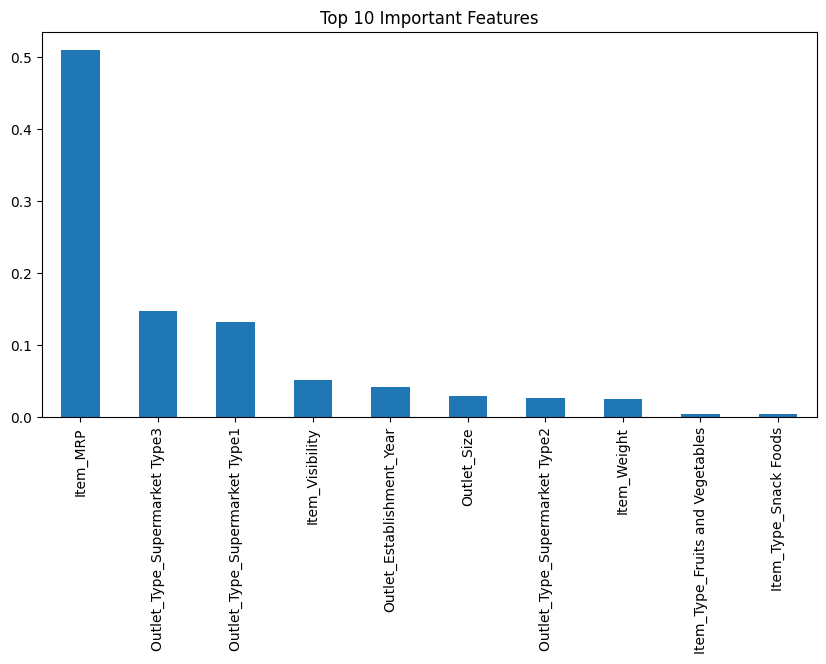

In [29]:
import pandas as pd
import matplotlib.pyplot as plt

feature_importance = pd.Series(rf.feature_importances_, index=X.columns)
feature_importance = feature_importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))
feature_importance[:10].plot(kind="bar")
plt.title("Top 10 Important Features")
plt.show()

8. Prediction

In [30]:
predictions = model.predict(X_test)
predictions[:5]

array([1356.6771214 ,  701.74152425,  898.59875613, 4233.01996542,
       3269.31106512])

9. Data Visualization

Text(0.5, 1.0, 'Sales Distribution')

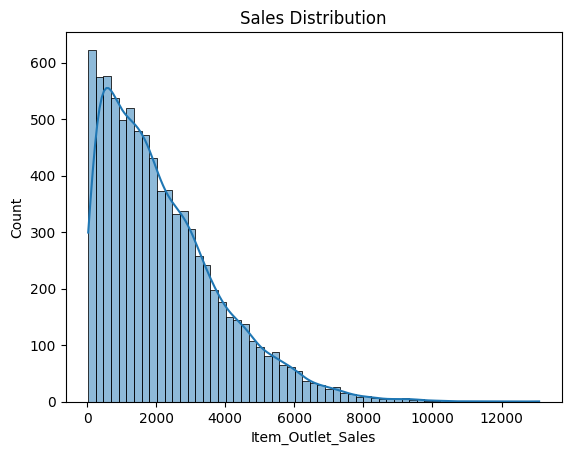

In [31]:
sns.histplot(df['Item_Outlet_Sales'], kde=True)
plt.title("Sales Distribution")

([0, 1, 2], [Text(0, 0, '0'), Text(1, 0, '1'), Text(2, 0, '2')])

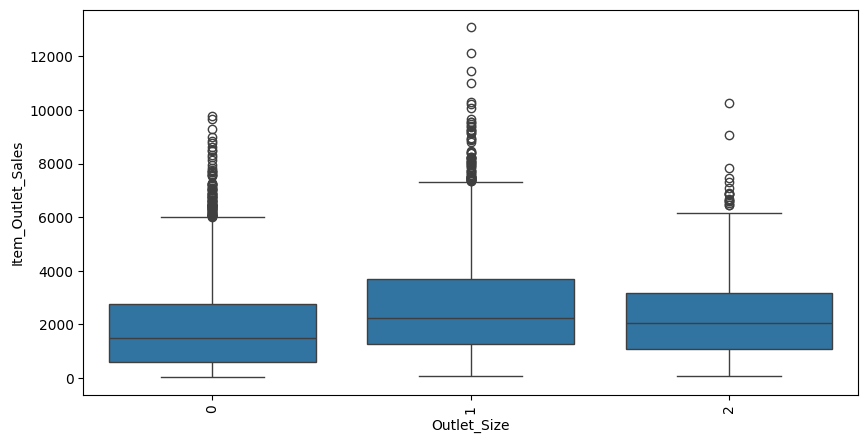

In [32]:
plt.figure(figsize=(10,5))
sns.boxplot(x='Outlet_Size', y='Item_Outlet_Sales', data=df) # Changed 'Item_Type' to 'Outlet_Size'
plt.xticks(rotation=90)

<Axes: xlabel='Outlet_Location_Type_Tier 3', ylabel='Item_Outlet_Sales'>

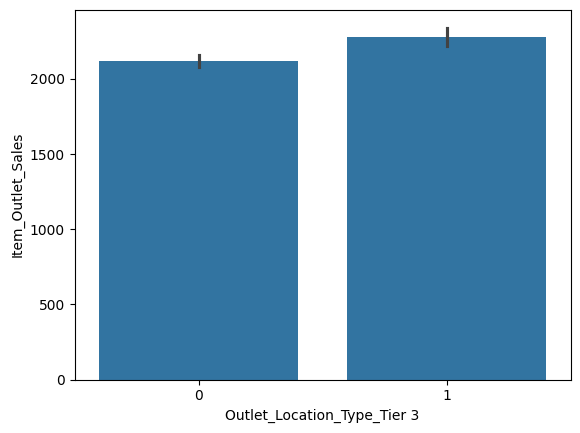

In [33]:
sns.barplot(x=df['Outlet_Location_Type_Tier 3'].astype(str), y='Item_Outlet_Sales', data=df)

#10. Conclusion:
Random Forest performed better than Linear Regression in predicting BigMart sales.
The analysis shows that outlet type and product features influence sales significantly.